<a href="https://www.kaggle.com/code/muhammadtalha82/suicide-rates-per-country-and-continent-wise?scriptVersionId=304655668" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lucalullo/global-suicide-rates-by-country-2000-2021/tassi-di-suicidio-globali-per-paese-2000-2021.csv


In [2]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split


In [3]:
df=pd.read_csv('/kaggle/input/datasets/lucalullo/global-suicide-rates-by-country-2000-2021/tassi-di-suicidio-globali-per-paese-2000-2021.csv')
df

,iso_code,country,year,sex,age_group,suicide_rate
0,AFG,Afghanistan,2000,male,ALL,5.793457
1,AFG,Afghanistan,2000,both,ALL,4.356148
2,AFG,Afghanistan,2000,female,ALL,2.910393
3,AFG,Afghanistan,2001,male,ALL,5.831328
4,AFG,Afghanistan,2001,both,ALL,4.383031
...,...,...,...,...,...,...
18310,ZWE,Zimbabwe,2021,male,20_29,24.592566
18311,ZWE,Zimbabwe,2021,male,15_29,22.297359
18312,ZWE,Zimbabwe,2021,female,15_19,9.802394
18313,ZWE,Zimbabwe,2021,both,50_59,49.098438


In [4]:
all_countries=df["country"].unique()

import pandas as pd

# Creating the mapping dictionary
country_to_continent = {
    # AFRICA
    'Angola': 'Africa', 'Benin': 'Africa', 'Botswana': 'Africa', 'Burkina Faso': 'Africa', 'Burundi': 'Africa',
    'Cabo Verde': 'Africa', 'Cameroon': 'Africa', 'Central African Republic': 'Africa', 'Chad': 'Africa',
    'Comoros': 'Africa', 'Republic of the Congo': 'Africa', 'Democratic Republic of the Congo': 'Africa',
    'Côte d’Ivoire': 'Africa', 'Djibouti': 'Africa', 'Egypt': 'Africa', 'Equatorial Guinea': 'Africa',
    'Eritrea': 'Africa', 'Eswatini': 'Africa', 'Ethiopia': 'Africa', 'Gabon': 'Africa', 'Gambia': 'Africa',
    'Ghana': 'Africa', 'Guinea': 'Africa', 'Guinea-Bissau': 'Africa', 'Kenya': 'Africa', 'Lesotho': 'Africa',
    'Liberia': 'Africa', 'Libya': 'Africa', 'Madagascar': 'Africa', 'Malawi': 'Africa', 'Mali': 'Africa',
    'Mauritania': 'Africa', 'Mauritius': 'Africa', 'Morocco': 'Africa', 'Mozambique': 'Africa', 'Namibia': 'Africa',
    'Niger': 'Africa', 'Nigeria': 'Africa', 'Rwanda': 'Africa', 'São Tomé and Príncipe': 'Africa', 'Senegal': 'Africa',
    'Seychelles': 'Africa', 'Sierra Leone': 'Africa', 'Somalia': 'Africa', 'South Africa': 'Africa',
    'South Sudan': 'Africa', 'Sudan': 'Africa', 'Tanzania': 'Africa', 'Togo': 'Africa', 'Tunisia': 'Africa',
    'Uganda': 'Africa', 'Zambia': 'Africa', 'Zimbabwe': 'Africa', 'Algeria': 'Africa',

    # ASIA
    'Afghanistan': 'Asia', 'Armenia': 'Asia', 'Azerbaijan': 'Asia', 'Bahrain': 'Asia', 'Bangladesh': 'Asia',
    'Bhutan': 'Asia', 'Brunei': 'Asia', 'Cambodia': 'Asia', 'China': 'Asia', 'Cyprus': 'Asia', 'Georgia': 'Asia',
    'India': 'Asia', 'Indonesia': 'Asia', 'Iran': 'Asia', 'Iraq': 'Asia', 'Israel': 'Asia', 'Japan': 'Asia',
    'Jordan': 'Asia', 'Kazakhstan': 'Asia', 'Kuwait': 'Asia', 'Kyrgyzstan': 'Asia', 'Laos': 'Asia', 'Lebanon': 'Asia',
    'Malaysia': 'Asia', 'Maldives': 'Asia', 'Mongolia': 'Asia', 'Myanmar': 'Asia', 'Nepal': 'Asia', 'North Korea': 'Asia',
    'Oman': 'Asia', 'Pakistan': 'Asia', 'Palestine': 'Asia', 'Philippines': 'Asia', 'Qatar': 'Asia', 'Saudi Arabia': 'Asia',
    'Singapore': 'Asia', 'South Korea': 'Asia', 'Sri Lanka': 'Asia', 'Syria': 'Asia', 'Tajikistan': 'Asia',
    'Thailand': 'Asia', 'Timor-Leste': 'Asia', 'Türkiye': 'Asia', 'Turkmenistan': 'Asia', 'United Arab Emirates': 'Asia',
    'Uzbekistan': 'Asia', 'Vietnam': 'Asia', 'Yemen': 'Asia',

    # EUROPE
    'Albania': 'Europe', 'Austria': 'Europe', 'Belarus': 'Europe', 'Belgium': 'Europe', 'Bosnia and Herzegovina': 'Europe',
    'Bulgaria': 'Europe', 'Croatia': 'Europe', 'Czechia': 'Europe', 'Denmark': 'Europe', 'Estonia': 'Europe',
    'Finland': 'Europe', 'France': 'Europe', 'Germany': 'Europe', 'Greece': 'Europe', 'Hungary': 'Europe',
    'Iceland': 'Europe', 'Ireland': 'Europe', 'Italy': 'Europe', 'Latvia': 'Europe', 'Lithuania': 'Europe',
    'Luxembourg': 'Europe', 'Malta': 'Europe', 'Moldova': 'Europe', 'Montenegro': 'Europe', 'Netherlands': 'Europe',
    'North Macedonia': 'Europe', 'Norway': 'Europe', 'Poland': 'Europe', 'Portugal': 'Europe', 'Romania': 'Europe',
    'Russia': 'Europe', 'Serbia': 'Europe', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Spain': 'Europe',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'Ukraine': 'Europe', 'United Kingdom': 'Europe',

    # NORTH AMERICA (includes Caribbean/Central)
    'Antigua and Barbuda': 'North America', 'Bahamas': 'North America', 'Barbados': 'North America',
    'Belize': 'North America', 'Canada': 'North America', 'Costa Rica': 'North America', 'Cuba': 'North America',
    'Dominican Republic': 'North America', 'El Salvador': 'North America', 'Grenada': 'North America',
    'Guatemala': 'North America', 'Haiti': 'North America', 'Honduras': 'North America', 'Jamaica': 'North America',
    'Mexico': 'North America', 'Nicaragua': 'North America', 'Panama': 'North America', 'Puerto Rico': 'North America',
    'Saint Lucia': 'North America', 'Saint Vincent and the Grenadines': 'North America',
    'Trinidad and Tobago': 'North America', 'United States': 'North America',

    # SOUTH AMERICA
    'Argentina': 'South America', 'Bolivia': 'South America', 'Brazil': 'South America', 'Chile': 'South America',
    'Colombia': 'South America', 'Ecuador': 'South America', 'Guyana': 'South America', 'Paraguay': 'South America',
    'Peru': 'South America', 'Suriname': 'South America', 'Uruguay': 'South America', 'Venezuela': 'South America',

    # OCEANIA
    'Australia': 'Oceania', 'Fiji': 'Oceania', 'Kiribati': 'Oceania', 'Micronesia': 'Oceania', 'New Zealand': 'Oceania',
    'Papua New Guinea': 'Oceania', 'Samoa': 'Oceania', 'Solomon Islands': 'Oceania', 'Tonga': 'Oceania', 'Vanuatu': 'Oceania'
}

df['Continent'] = df['country'].map(country_to_continent)
df

,iso_code,country,year,sex,age_group,suicide_rate,Continent
0,AFG,Afghanistan,2000,male,ALL,5.793457,Asia
1,AFG,Afghanistan,2000,both,ALL,4.356148,Asia
2,AFG,Afghanistan,2000,female,ALL,2.910393,Asia
3,AFG,Afghanistan,2001,male,ALL,5.831328,Asia
4,AFG,Afghanistan,2001,both,ALL,4.383031,Asia
...,...,...,...,...,...,...,...
18310,ZWE,Zimbabwe,2021,male,20_29,24.592566,Africa
18311,ZWE,Zimbabwe,2021,male,15_29,22.297359,Africa
18312,ZWE,Zimbabwe,2021,female,15_19,9.802394,Africa
18313,ZWE,Zimbabwe,2021,both,50_59,49.098438,Africa


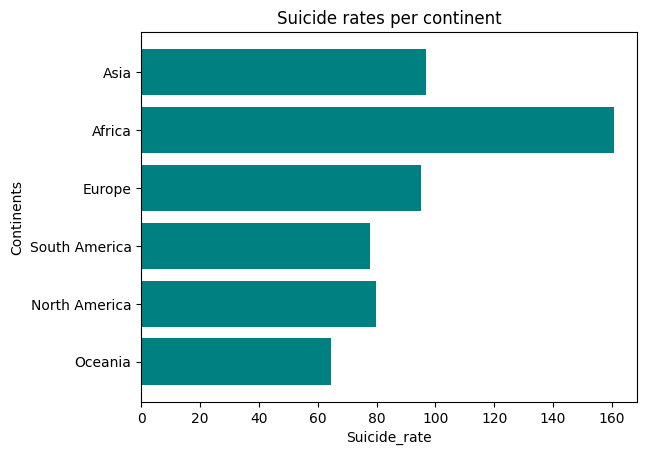

In [5]:
import matplotlib.pyplot as plt
plt.barh(df['Continent'],df['suicide_rate'],color='teal')
# Add labels and title
plt.ylabel('Continents')
plt.xlabel('Suicide_rate')
plt.title('Suicide rates per continent')
plt.gca().invert_yaxis()
# Display
plt.show()

In [6]:
df.isna().any()

iso_code        False
country         False
year            False
sex             False
age_group       False
suicide_rate    False
Continent       False
dtype: bool

In [7]:
X=df.drop(columns=['suicide_rate','iso_code'])
y=df.suicide_rate


In [8]:
cols=['country','sex','age_group','Continent']


In [9]:
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state = 0)

encoder=OrdinalEncoder()
train_X=encoder.fit_transform(train_X[cols])
val_X=encoder.fit_transform(val_X[cols])


**MI Score: Relationship of features with Target variable**

In [10]:
X = df.drop(columns='iso_code').copy()
y = X.pop("suicide_rate")

# Label encoding for categoricals
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

# All discrete features should now have integer dtypes (double-check this before using MI!)
discrete_features = X.dtypes == int

In [11]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores  # show a few features with their MI scores

country      0.834824
sex          0.134224
Continent    0.121907
age_group    0.048131
year         0.008644
Name: MI Scores, dtype: float64

**plot showing MI scores on relationship between features and taregt.**

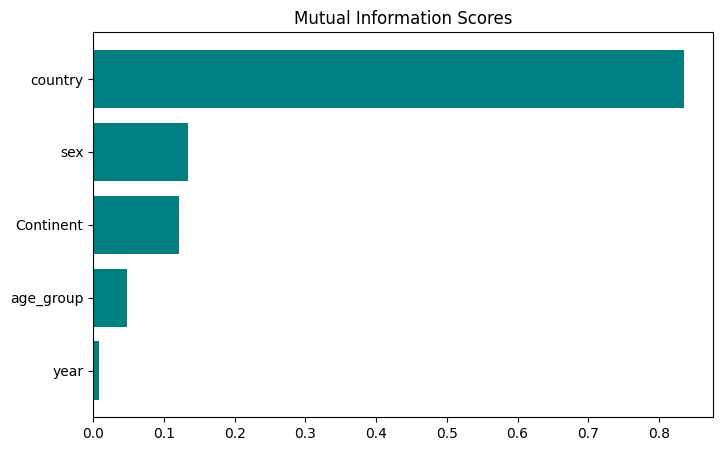

In [12]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores, color='teal')
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

**Creating XGBRegressor model.**

In [13]:
model=XGBRegressor(n_estimators=1000, learning_rate=0.1)
fitted=model.fit(train_X,train_y)
predict=fitted.predict(val_X)
mae=mean_absolute_error(val_y, predict)
print('mae: ',mae)

mae:  1.768431856005892


**Showing comparison of Actual or Observed VS Predicted Suicide_rate.**

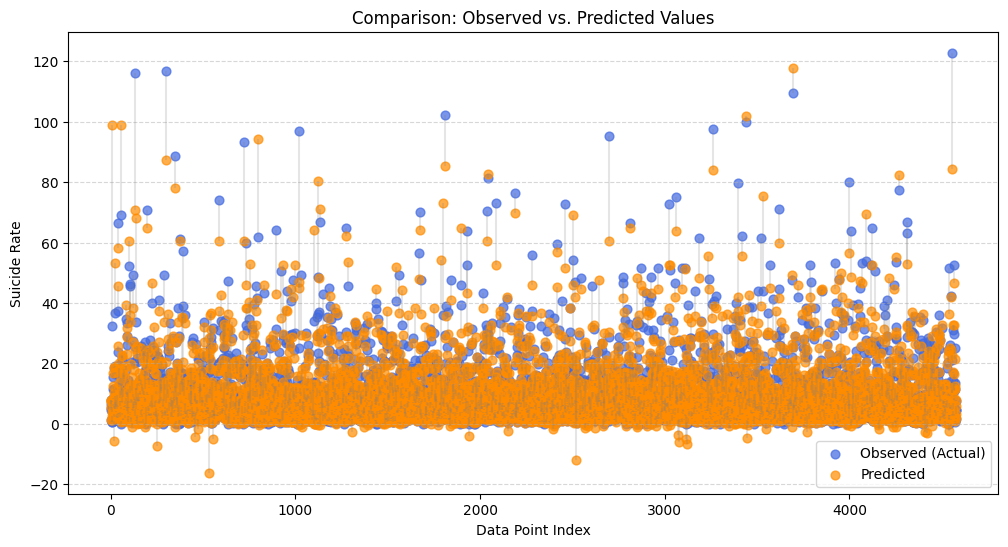

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Create an index for the x-axis
index = np.arange(len(val_y))

plt.figure(figsize=(12, 6))

# Plot Observed in one color
plt.scatter(index, val_y, color='royalblue', label='Observed (Actual)', alpha=0.7, s=40)

# Plot Predicted in another color
plt.scatter(index, predict, color='darkorange', label='Predicted', alpha=0.7, s=40)

# Optional: Add a line to connect them to show the "gap" (error)
plt.vlines(index, val_y, predict, color='gray', alpha=0.2, linestyles='solid')

plt.xlabel('Data Point Index')
plt.ylabel('Suicide Rate')
plt.title('Comparison: Observed vs. Predicted Values')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()

**PLot showing Residuals and Fitting of data**

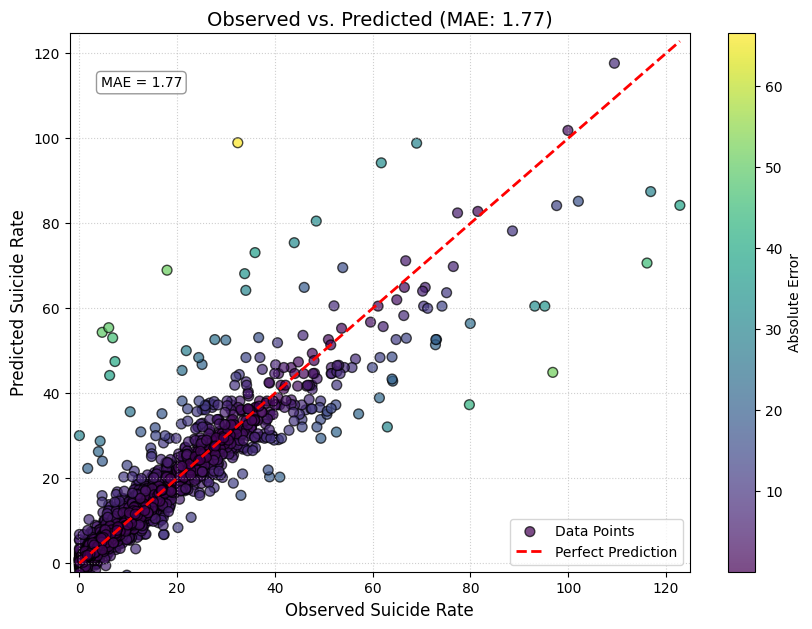

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the error for each point
error = np.abs(val_y - predict)
mae = 1.7684  # Your calculated MAE

plt.figure(figsize=(10, 7))

# 1. Scatter Plot: Color the points by the size of the error
# We use 'coolwarm' or 'viridis' to show intensity
scatter = plt.scatter(val_y, predict, c=error, cmap='viridis', 
                      alpha=0.7, edgecolors='k', s=50, label='Data Points')

# 2. Reference Line: The "Perfect Prediction" line (y = x)
line_min, line_max = val_y.min(), val_y.max()
plt.plot([line_min, line_max], [line_min, line_max], 
         color='red', linestyle='--', lw=2, label='Perfect Prediction')

# 3. Adjusting the Scale
# We set the padding so the points aren't hugging the edges
plt.xlim(line_min - 2, line_max + 2)
plt.ylim(line_min - 2, line_max + 2)

# 4. Labels and Visuals
plt.colorbar(scatter, label='Absolute Error')
plt.xlabel('Observed Suicide Rate', fontsize=12)
plt.ylabel('Predicted Suicide Rate', fontsize=12)
plt.title(f'Observed vs. Predicted (MAE: {mae:.2f})', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Annotation for clarity
plt.annotate(f'MAE = {mae:.2f}', xy=(0.05, 0.90), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

plt.show()